# Brazilian E-Commerce Business Analysis

## Notebook 2 – Business Analytics

---

## Project Overview

This notebook presents a comprehensive business analysis of the Brazilian E-Commerce Public Dataset (Olist). The objective is to transform transactional data into actionable business insights that support decision-making in sales, customer management, logistics, and business strategy.

The notebook uses the analytical dataset generated in **Notebook 1 (Data Profiling & Cleaning)** as the primary data source.

# Table of Contents

1. Business Understanding
2. Dataset Overview
3. Data Preparation
4. Visualization Theme
5. Executive Overview
6. Sales Performance Analysis
7. Customer Behavior Analysis
8. Customer Analytics
9. Operational Analysis
10. Executive Summary
11. Strategic Recommendations

# Business Understanding

## Business Problem

As Olist continues to expand its marketplace, management requires business insights to understand sales performance, customer purchasing behavior, payment preferences, logistics efficiency, and customer satisfaction.

This analysis aims to answer these business questions using historical transaction data and provide recommendations that support data-driven decision-making.

# Dataset Overview

The dataset used in this notebook is an analytical dataset created in Notebook 1 after completing:

- Data Cleaning
- Data Integration
- Missing Value Handling
- Duplicate Removal
- Feature Engineering

This analytical dataset is specifically designed for business analytics and dashboard development.

In [361]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Plot settings
plt.style.use("ggplot")

In [362]:
# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("../data/processed/olist_analytical_dataset.csv")

In [363]:
# ==========================
# Convert Datetime Columns
# ==========================

datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "order_year_month"
]

for col in datetime_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_unique_id             119143 non-null  object        
 2   customer_city                  119143 non-null  object        
 3   customer_state                 119143 non-null  object        
 4   seller_city                    118310 non-null  object        
 5   seller_state                   118310 non-null  object        
 6   product_category_name_english  116576 non-null  object        
 7   payment_type                   119140 non-null  object        
 8   payment_installments           119140 non-null  float64       
 9   payment_value                  119140 non-null  float64       
 10  price                          118310 non-null  float64       
 11  

In [365]:
df.head()

,order_id,customer_unique_id,customer_city,customer_state,seller_city,seller_state,product_category_name_english,payment_type,payment_installments,payment_value,price,freight_value,order_value,review_score,review_category,delivery_time,delivery_delay,delivery_status,purchase_year,purchase_month,purchase_weekday,purchase_hour,purchase_quarter,order_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,credit_card,1.00,18.12,29.99,8.72,38.71,4.00,Good,8.00,-8.00,On Time,2017,10,Monday,10,Q4,2017-10-01
1,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,voucher,1.00,2.00,29.99,8.72,38.71,4.00,Good,8.00,-8.00,On Time,2017,10,Monday,10,Q4,2017-10-01
2,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,voucher,1.00,18.59,29.99,8.72,38.71,4.00,Good,8.00,-8.00,On Time,2017,10,Monday,10,Q4,2017-10-01
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,barreiras,BA,belo horizonte,SP,perfumery,boleto,1.00,141.46,118.70,22.76,141.46,4.00,Good,13.00,-6.00,On Time,2018,7,Tuesday,20,Q3,2018-07-01
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,guariba,SP,auto,credit_card,3.00,179.12,159.90,19.22,179.12,5.00,Excellent,9.00,-18.00,On Time,2018,8,Wednesday,8,Q3,2018-08-01


In [366]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,119143,99441,895ab968e7bb0d5659d16cd74cd1650c,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,119143,96096,9a736b248f67d166d2fbb006bcb877c3,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_city,119143,4119,sao paulo,18875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,119143,27,SP,50265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_city,118310,611,sao paulo,29293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,118310,23,SP,84377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name_english,116576,71,bed_bath_table,11988,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_type,119140,5,credit_card,87776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_installments,"119,140.00",NaN,NaN,NaN,2.94,0.00,1.00,2.00,4.00,24.00,2.78
payment_value,"119,140.00",NaN,NaN,NaN,172.74,0.00,60.85,108.16,189.24,"13,664.08",267.78


# Visualization Theme

A consistent visual theme is applied throughout this notebook to improve readability and maintain a professional appearance.

In [367]:
# Theme Configuration

PRIMARY = "#2E8B57"
SECONDARY = "#66C2A5"
ACCENT = "#F4A261"

FIGSIZE = (12, 5)

TITLE_SIZE = 16
LABEL_SIZE = 12
TICK_SIZE = 10

In [368]:
# Currency Formatter

def currency_formatter(x, pos):

    if x >= 1_000_000:
        return f"R$ {x/1_000_000:.1f}M"

    elif x >= 1_000:
        return f"R$ {x/1_000:.0f}K"

    return f"R$ {x:.0f}"

In [369]:
# Bar Label

def add_value_labels(ax):
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            fontsize=9,
            padding=3
        )

In [370]:
# Line Chart

def plot_line(data, x, y, title, ylabel="", currency=False):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(
        data[x],
        data[y],
        marker="o",
        linewidth=2.5,
        color=PRIMARY
    )

    if currency:
        ax.yaxis.set_major_formatter(
            FuncFormatter(currency_formatter)
        )

    ax.set_title(title, fontsize=TITLE_SIZE, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    plt.xticks(rotation=45)
    ax.grid(alpha=0.25, linestyle="--")
    plt.tight_layout()
    plt.show()

In [371]:
# Vertical Bar Chart

def plot_bar(data, x, y, title, currency=False, rotate=False):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    sns.barplot(
        data=data,
        x=x,
        y=y,
        color=PRIMARY,
        ax=ax
    )

    if currency:
        ax.yaxis.set_major_formatter(
            FuncFormatter(currency_formatter)
        )

    add_value_labels(ax)
    ax.set_title(title, fontsize=TITLE_SIZE, weight="bold")
    
    if rotate:
        plt.xticks(rotation=45)
        
    ax.grid(alpha=0.25, linestyle="--")
    plt.tight_layout()
    plt.show()

In [372]:
# Horizontal Bar Chart

def plot_horizontal(data, x, y, title, currency=False):
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=data,
        x=x,
        y=y,
        color=PRIMARY,
        ax=ax
    )

    if currency:
        ax.xaxis.set_major_formatter(
            FuncFormatter(currency_formatter)
        )

    add_value_labels(ax)
    ax.set_title(title, fontsize=TITLE_SIZE, weight="bold")
    ax.grid(alpha=0.25, linestyle="--")
    plt.tight_layout()
    plt.show()

In [373]:
# Growth Calculator

def calculate_growth(series):
    return (
        series
        .pct_change()
        .mul(100)
        .round(2)
    )

# Executive Overview

The Executive Overview provides a high-level summary of Olist's business performance before exploring detailed analyses.

## Business Question 1

### What is the overall business performance?

#### Business Context

Executive management requires a concise summary of the company's overall performance to monitor business growth and support strategic decision-making.

In [374]:
summary = pd.DataFrame({

    "KPI": [
        "Total Orders",
        "Total Customers",
        "Total Revenue",
        "Average Order Value",
        "Average Review Score",
        "Average Delivery Time"
    ],

    "Value": [
        df["order_id"].nunique(),
        df["customer_unique_id"].nunique(),
        f"R$ {df['payment_value'].sum():,.2f}",
        f"R$ {df.groupby('order_id')['payment_value'].sum().mean():,.2f}",
        round(df["review_score"].mean(), 2),
        round(df["delivery_time"].mean(), 2)
    ]
})

summary

,KPI,Value
0,Total Orders,99441
1,Total Customers,96096
2,Total Revenue,"R$ 20,579,664.01"
3,Average Order Value,R$ 206.95
4,Average Review Score,4.02
5,Average Delivery Time,12.02


### Business Insight

The executive KPI summary indicates that Olist has processed a substantial number of orders, served a large customer base, and generated significant revenue during the observation period. These key metrics provide the foundation for evaluating sales performance, customer behavior, and operational efficiency in the following sections.

### Managerial Implication

Executive management should continuously monitor these KPIs to assess business performance and identify potential opportunities or risks.

### Recommendation

Develop an executive dashboard that displays these KPIs in real time to support faster and more informed business decisions.

## Business Question 2

### How has total revenue changed over time?

#### Business Context

Revenue trend analysis helps management evaluate business growth, identify seasonal patterns, and monitor long-term marketplace performance.

#### Analysis

The following analysis aggregates total payment by month to evaluate how business revenue changes over time.

In [375]:
monthly_revenue = (
    df.groupby("order_year_month", as_index=False)
      .agg(
          Revenue=("payment_value", "sum")
      )
      .sort_values("order_year_month")
)

monthly_revenue

,order_year_month,Revenue
0,2016-09-01,388.47
1,2016-10-01,"76,559.05"
2,2016-12-01,19.62
3,2017-01-01,"190,806.27"
4,2017-02-01,"351,848.13"
5,2017-03-01,"547,769.84"
6,2017-04-01,"512,126.52"
7,2017-05-01,"737,425.31"
8,2017-06-01,"613,777.41"
9,2017-07-01,"749,242.84"


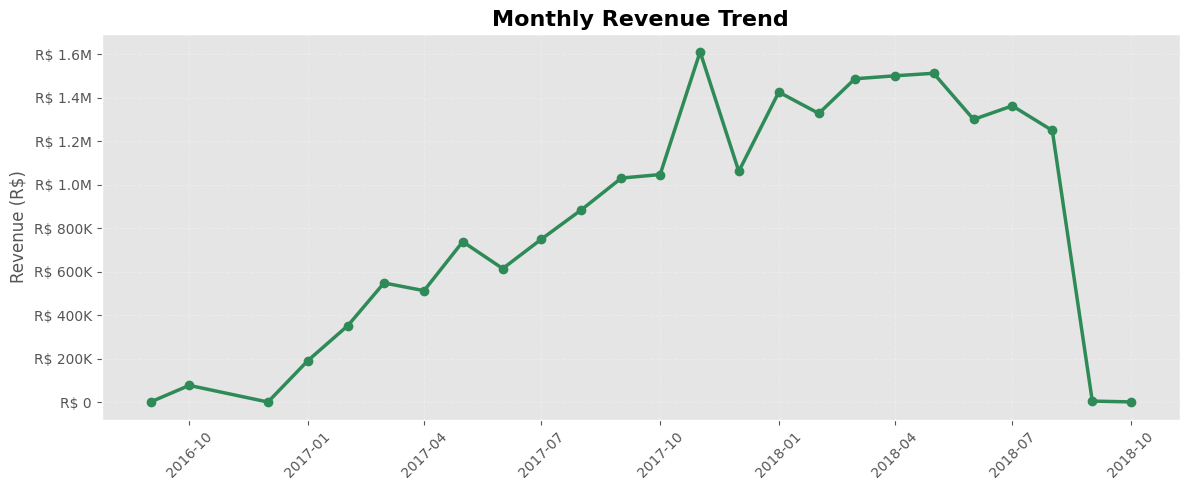

In [376]:
plot_line(
    data=monthly_revenue,
    x="order_year_month",
    y="Revenue",
    title="Monthly Revenue Trend",
    ylabel="Revenue (R$)",
    currency=True
)

In [377]:
peak_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

pd.DataFrame({
    "Metric": [
        "Highest Revenue Month",
        "Lowest Revenue Month"
    ],
    "Month": [
        peak_month["order_year_month"].strftime("%Y-%m"),
        lowest_month["order_year_month"].strftime("%Y-%m")
    ],
    "Revenue": [
        peak_month["Revenue"],
        lowest_month["Revenue"]
    ]
})

,Metric,Month,Revenue
0,Highest Revenue Month,2017-11,"1,610,581.21"
1,Lowest Revenue Month,2016-12,19.62


### Business Insight

The monthly revenue trend indicates that Olist experienced steady business growth throughout the observation period. Revenue reached its highest level during the year-end shopping season, while the lowest revenue was observed during the early stage of marketplace operations.

### Managerial Implication

The company demonstrates sustainable business growth, suggesting increasing customer adoption and marketplace maturity.

### Recommendation

Maintain successful marketing strategies during high-performing periods and prepare inventory and logistics resources ahead of seasonal demand.

### Business Insight

The monthly revenue trend indicates that Olist experienced steady business growth throughout the observation period. Revenue reached its highest level during the year-end shopping season, while the lowest revenue was observed during the early stage of marketplace operations.

### Managerial Implication

The company demonstrates sustainable business growth, suggesting increasing customer adoption and marketplace maturity.

### Recommendation

Maintain successful marketing strategies during high-performing periods and prepare inventory and logistics resources ahead of seasonal demand.

In [378]:
monthly_orders = (
    df.groupby("order_year_month", as_index=False)
      .agg(
          Orders=("order_id", "nunique")
      )
      .sort_values("order_year_month")
)

monthly_orders

,order_year_month,Orders
0,2016-09-01,4
1,2016-10-01,324
2,2016-12-01,1
3,2017-01-01,800
4,2017-02-01,1780
5,2017-03-01,2682
6,2017-04-01,2404
7,2017-05-01,3700
8,2017-06-01,3245
9,2017-07-01,4026


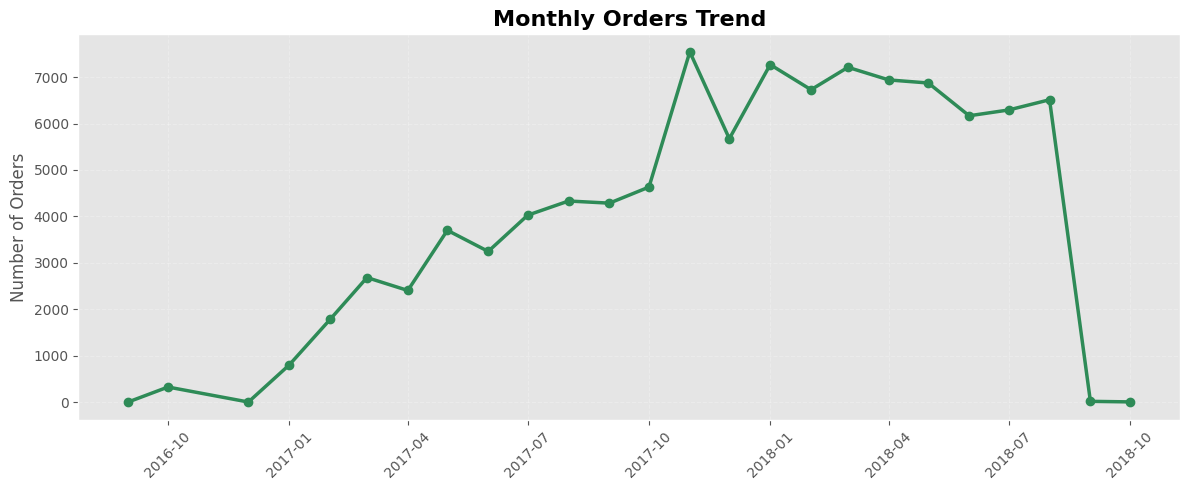

In [379]:
plot_line(
    data=monthly_orders,
    x="order_year_month",
    y="Orders",
    title="Monthly Orders Trend",
    ylabel="Number of Orders"
)

In [380]:
peak_orders = monthly_orders.loc[
    monthly_orders["Orders"].idxmax()
]

lowest_orders = monthly_orders.loc[
    monthly_orders["Orders"].idxmin()
]

pd.DataFrame({
    "Metric": [
        "Highest Orders Month",
        "Lowest Orders Month"
    ],
    "Month": [
        peak_orders["order_year_month"].strftime("%Y-%m"),
        lowest_orders["order_year_month"].strftime("%Y-%m")
    ],
    "Orders": [
        peak_orders["Orders"],
        lowest_orders["Orders"]
    ]
})

,Metric,Month,Orders
0,Highest Orders Month,2017-11,7544
1,Lowest Orders Month,2016-12,1


### Business Insight

Monthly order volume follows a growth pattern similar to revenue, indicating that business expansion is primarily driven by increasing customer transactions rather than isolated high-value purchases.

### Managerial Implication

A growing order volume reflects increasing marketplace adoption and stronger customer engagement over time.

### Recommendation

Continue customer acquisition initiatives while ensuring operational capacity can support future order growth.

## Business Question 4

### How has the number of active customers changed over time?

#### Business Context

Understanding customer growth helps evaluate marketplace expansion and the effectiveness of customer acquisition strategies.

#### Analysis

This analysis measures the number of unique customers making purchases each month.

In [381]:
monthly_customers = (
    df.groupby("order_year_month", as_index=False)
      .agg(
          Customers=("customer_unique_id", "nunique")
      )
      .sort_values("order_year_month")
)

monthly_customers

,order_year_month,Customers
0,2016-09-01,4
1,2016-10-01,321
2,2016-12-01,1
3,2017-01-01,765
4,2017-02-01,1755
5,2017-03-01,2642
6,2017-04-01,2372
7,2017-05-01,3625
8,2017-06-01,3180
9,2017-07-01,3947


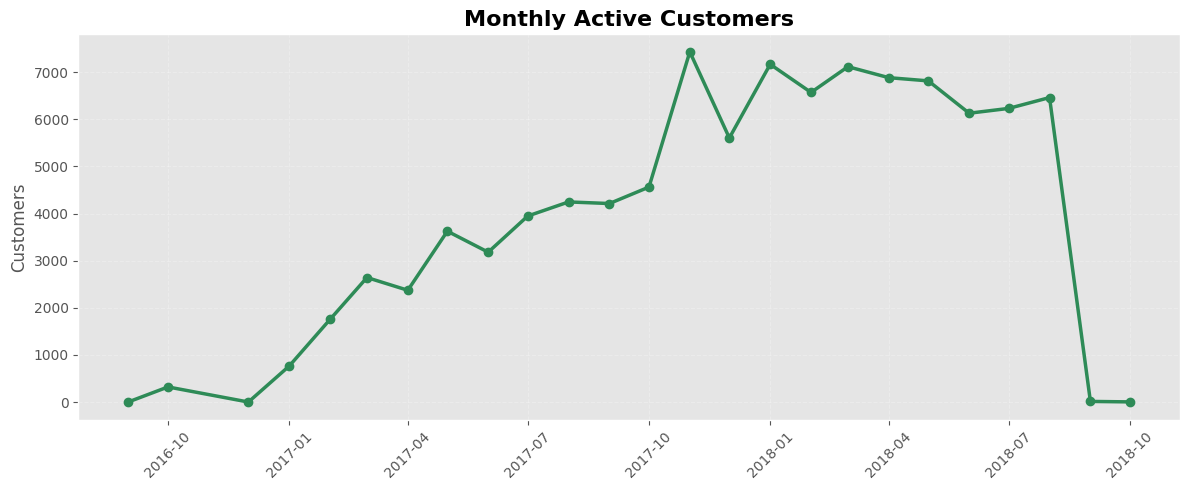

In [382]:
plot_line(
    data=monthly_customers,
    x="order_year_month",
    y="Customers",
    title="Monthly Active Customers",
    ylabel="Customers"
)

In [383]:
peak_customer = monthly_customers.loc[
    monthly_customers["Customers"].idxmax()
]

pd.DataFrame({
    "Metric": [
        "Highest Customer Month"
    ],
    "Month": [
        peak_customer["order_year_month"].strftime("%Y-%m")
    ],
    "Customers": [
        peak_customer["Customers"]
    ]
})

,Metric,Month,Customers
0,Highest Customer Month,2017-11,7430


### Business Insight

The number of active customers increased steadily throughout the observation period, demonstrating continuous marketplace expansion and successful customer acquisition efforts.

### Managerial Implication

Customer growth is one of the primary drivers behind increasing revenue and order volume.

### Recommendation

Continue investing in customer acquisition while strengthening customer retention to sustain long-term business growth.

### Business Insight

The number of active customers increased steadily throughout the observation period, demonstrating continuous marketplace expansion and successful customer acquisition efforts.

### Managerial Implication

Customer growth is one of the primary drivers behind increasing revenue and order volume.

### Recommendation

Continue investing in customer acquisition while strengthening customer retention to sustain long-term business growth.

In [384]:
monthly_growth = monthly_revenue.copy()

monthly_growth["Revenue Growth (%)"] = calculate_growth(
    monthly_growth["Revenue"]
)

monthly_growth

,order_year_month,Revenue,Revenue Growth (%)
0,2016-09-01,388.47,NaN
1,2016-10-01,"76,559.05","19,607.84"
2,2016-12-01,19.62,-99.97
3,2017-01-01,"190,806.27","972,409.02"
4,2017-02-01,"351,848.13",84.40
5,2017-03-01,"547,769.84",55.68
6,2017-04-01,"512,126.52",-6.51
7,2017-05-01,"737,425.31",43.99
8,2017-06-01,"613,777.41",-16.77
9,2017-07-01,"749,242.84",22.07


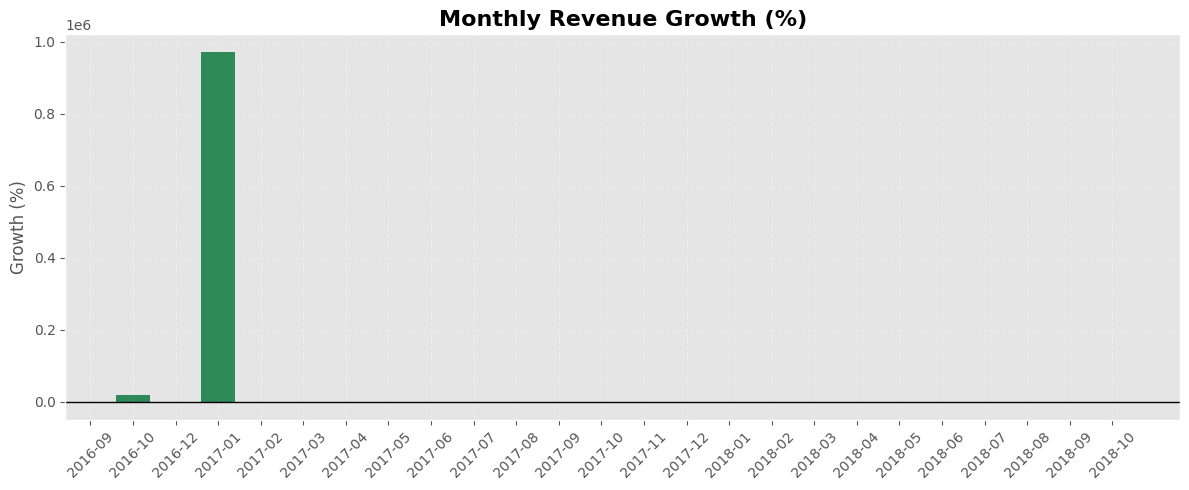

In [385]:
plt.figure(figsize=FIGSIZE)

colors = [
    PRIMARY if x >= 0 else "#D9534F"
    for x in monthly_growth["Revenue Growth (%)"].fillna(0)
]

plt.bar(
    monthly_growth["order_year_month"].dt.strftime("%Y-%m"),
    monthly_growth["Revenue Growth (%)"],
    color=colors
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.xticks(rotation=45)

plt.title(
    "Monthly Revenue Growth (%)",
    fontsize=TITLE_SIZE,
    weight="bold"
)

plt.ylabel("Growth (%)")

plt.grid(alpha=.25, linestyle="--")

plt.tight_layout()

plt.show()

### Business Insight

Revenue growth fluctuates over time but generally follows a positive trend, indicating that Olist successfully expanded its marketplace despite temporary slowdowns. Significant growth spikes may reflect seasonal demand or successful marketing campaigns.

### Managerial Implication

Monitoring growth rate provides a better understanding of business momentum than revenue alone.

### Recommendation

Investigate months with exceptional growth to identify successful business strategies that can be replicated in future campaigns.

## Business Question 6

### Which months generated the highest revenue?

#### Business Context

Identifying top-performing months helps management prepare inventory, logistics, staffing, and marketing campaigns for future high-demand periods.

#### Analysis

The following analysis ranks the ten highest-revenue months.

In [386]:
top_revenue_month = (
    monthly_revenue
    .sort_values(
        by="Revenue",
        ascending=False
    )
    .head(10)
)

top_revenue_month

,order_year_month,Revenue
13,2017-11-01,"1,610,581.21"
19,2018-05-01,"1,512,010.75"
18,2018-04-01,"1,500,373.12"
17,2018-03-01,"1,486,669.64"
15,2018-01-01,"1,425,461.40"
21,2018-07-01,"1,362,267.08"
16,2018-02-01,"1,327,338.97"
20,2018-06-01,"1,299,683.17"
22,2018-08-01,"1,248,942.63"
14,2017-12-01,"1,060,949.63"


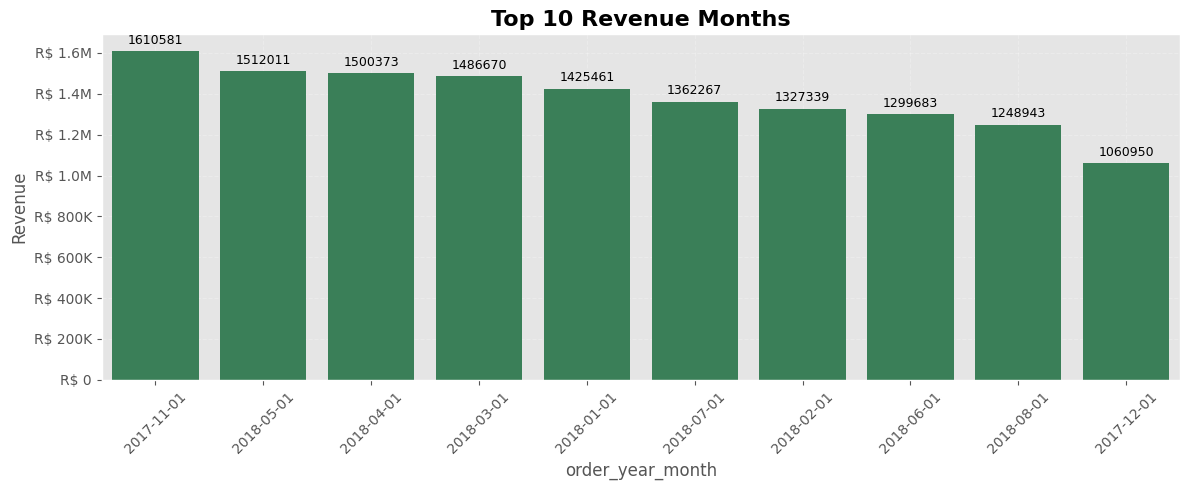

In [387]:
plot_bar(
    data=top_revenue_month,
    x="order_year_month",
    y="Revenue",
    title="Top 10 Revenue Months",
    rotate=True,
    currency=True
)

### Business Insight

Revenue is concentrated in several peak months, with November recording the highest revenue. This reflects strong seasonal purchasing behavior and highlights the importance of year-end sales periods.

### Managerial Implication

Seasonal demand has a measurable impact on business performance.

### Recommendation

Increase inventory availability, logistics capacity, and marketing investment before historically high-performing months to maximize revenue opportunities.

## Business Question 7

### What is the Average Order Value (AOV)?

#### Business Context

Average Order Value (AOV) measures the average amount spent per order and provides insight into customer purchasing behavior.

#### Analysis

The analysis calculates the average payment value across all unique orders.

In [388]:
order_value = (
    df.groupby("order_id")["payment_value"]
      .sum()
)

aov = order_value.mean()

median_order = order_value.median()

summary_aov = pd.DataFrame({
    "Metric": [
        "Average Order Value",
        "Median Order Value"
    ],
    "Value": [
        round(aov, 2),
        round(median_order, 2)
    ]
})

summary_aov

,Metric,Value
0,Average Order Value,206.95
1,Median Order Value,110.24


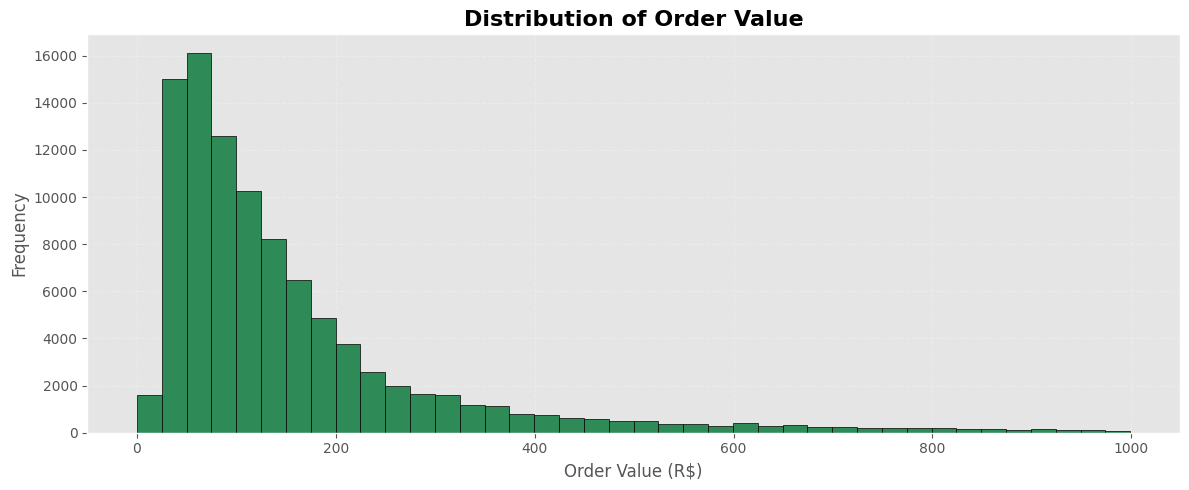

In [389]:
plt.figure(figsize=FIGSIZE)

plt.hist(
    order_value[order_value <= 1000],
    bins=40,
    color=PRIMARY,
    edgecolor="black"
)

plt.title(
    "Distribution of Order Value",
    fontsize=TITLE_SIZE,
    weight="bold"
)

plt.xlabel("Order Value (R$)")
plt.ylabel("Frequency")

plt.grid(alpha=.25, linestyle="--")

plt.tight_layout()

plt.show()

### Business Insight

The Average Order Value is higher than the median order value, indicating a right-skewed distribution. Most customers make relatively small purchases, while a limited number of high-value orders increase the overall average.

### Managerial Implication

Using only the average may overestimate typical customer spending.

### Recommendation

Track both average and median order values while implementing cross-selling and upselling strategies to increase customer basket size.

# Customer Behavior Analysis

Understanding customer behavior is essential for developing effective marketing strategies, improving customer experience, and increasing business performance.

This section explores purchasing patterns, payment preferences, and customer distribution across different regions.

## Business Question 8

### On which day of the week do customers spend the most?

#### Business Context

Customer purchasing behavior may vary across weekdays and weekends. Understanding these patterns helps optimize promotional campaigns and operational planning.

#### Analysis

This analysis compares total revenue generated on each day of the week.

In [390]:
weekday_revenue = (
    df.groupby("purchase_weekday", as_index=False)
      .agg(
          Revenue=("payment_value", "sum"),
          Orders=("order_id", "nunique")
      )
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue["purchase_weekday"] = pd.Categorical(
    weekday_revenue["purchase_weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_revenue = weekday_revenue.sort_values("purchase_weekday")

weekday_revenue

,purchase_weekday,Revenue,Orders
1,Monday,"3,347,786.31",16196
5,Tuesday,"3,361,564.89",15963
6,Wednesday,"3,198,612.69",15552
4,Thursday,"3,145,030.37",14761
0,Friday,"3,056,608.65",14122
2,Saturday,"2,172,171.12",10887
3,Sunday,"2,297,889.98",11960


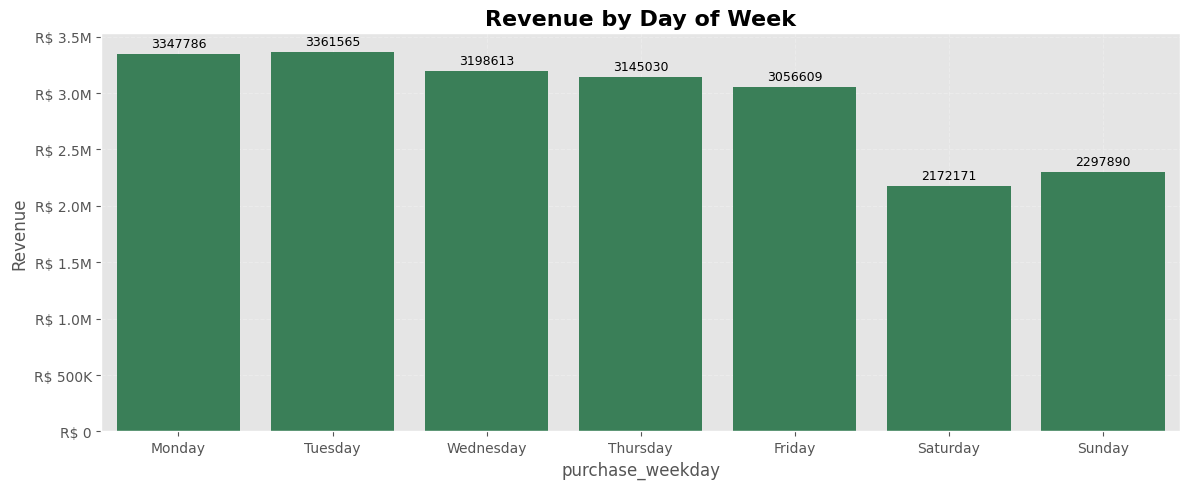

In [391]:
plot_bar(
    data=weekday_revenue,
    x="purchase_weekday",
    y="Revenue",
    title="Revenue by Day of Week",
    currency=True
)

### Business Insight

Customer spending is concentrated on weekdays, with Monday generating the highest revenue. Weekend transactions contribute a noticeably smaller proportion of total revenue.

### Managerial Implication

Customer purchasing behavior follows typical business-day activity, suggesting stronger engagement during the working week.

### Recommendation

Schedule major promotional campaigns on weekdays while introducing special weekend offers to stimulate additional demand.

## Business Question 9

### At what time do customers make the most purchases?

#### Business Context

Knowing peak purchasing hours enables businesses to optimize promotional timing, customer support availability, and operational capacity.

#### Analysis

This analysis evaluates customer purchasing activity throughout the day.

In [392]:
hourly_revenue = (
    df.groupby("purchase_hour", as_index=False)
      .agg(
          Revenue=("payment_value", "sum"),
          Orders=("order_id", "nunique")
      )
      .sort_values("purchase_hour")
)

hourly_revenue

,purchase_hour,Revenue,Orders
0,0,"474,801.20",2394
1,1,"210,304.96",1170
2,2,"92,701.68",510
3,3,"51,356.55",272
4,4,"36,004.52",206
5,5,"30,422.81",188
6,6,"82,144.98",502
7,7,"226,365.03",1231
8,8,"602,806.69",2967
9,9,"1,108,161.14",4785


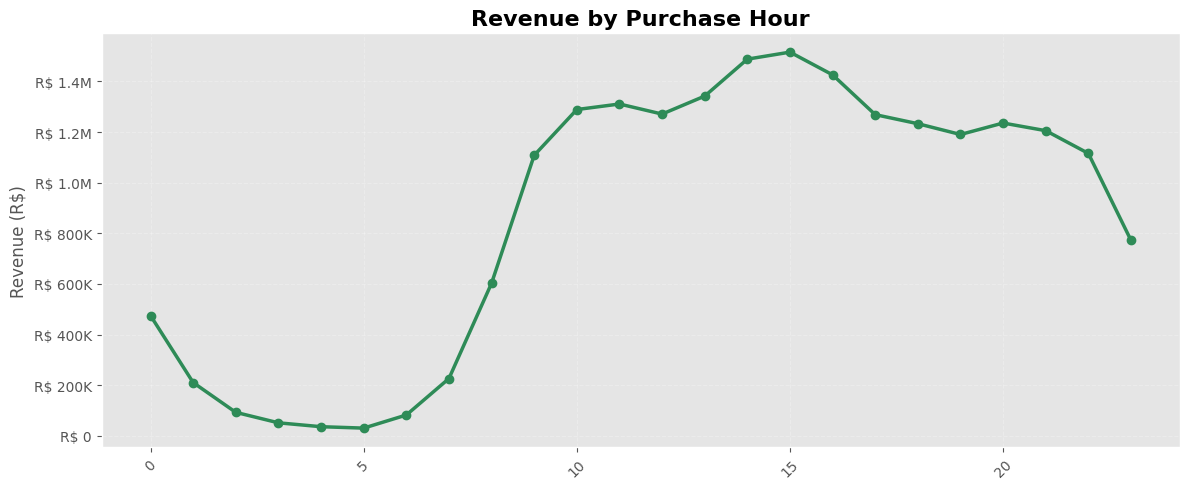

In [393]:
plot_line(
    data=hourly_revenue,
    x="purchase_hour",
    y="Revenue",
    title="Revenue by Purchase Hour",
    ylabel="Revenue (R$)",
    currency=True
)

### Business Insight

Customer purchasing activity gradually increases during the morning, reaches its peak in the afternoon, and declines during the evening. Very little purchasing activity occurs during the early morning hours.

### Managerial Implication

The afternoon represents the most valuable period for customer engagement and promotional campaigns.

### Recommendation

Schedule flash sales, advertisements, and customer engagement activities between 13:00 and 16:00 to maximize customer reach.

## Business Question 10

### Which payment methods generate the highest revenue?

#### Business Context

Understanding payment preferences helps improve the customer checkout experience and supports strategic partnerships with payment providers.

#### Analysis

This analysis compares total revenue generated by each payment method.

In [394]:
payment_summary = (
    df.groupby("payment_type", as_index=False)
      .agg(
          Revenue=("payment_value", "sum"),
          Orders=("order_id", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

payment_summary

,payment_type,Revenue,Orders
1,credit_card,"15,775,450.54",76505
0,boleto,"4,110,920.74",19784
4,voucher,"435,917.84",3866
2,debit_card,"257,374.89",1528
3,not_defined,0.00,3


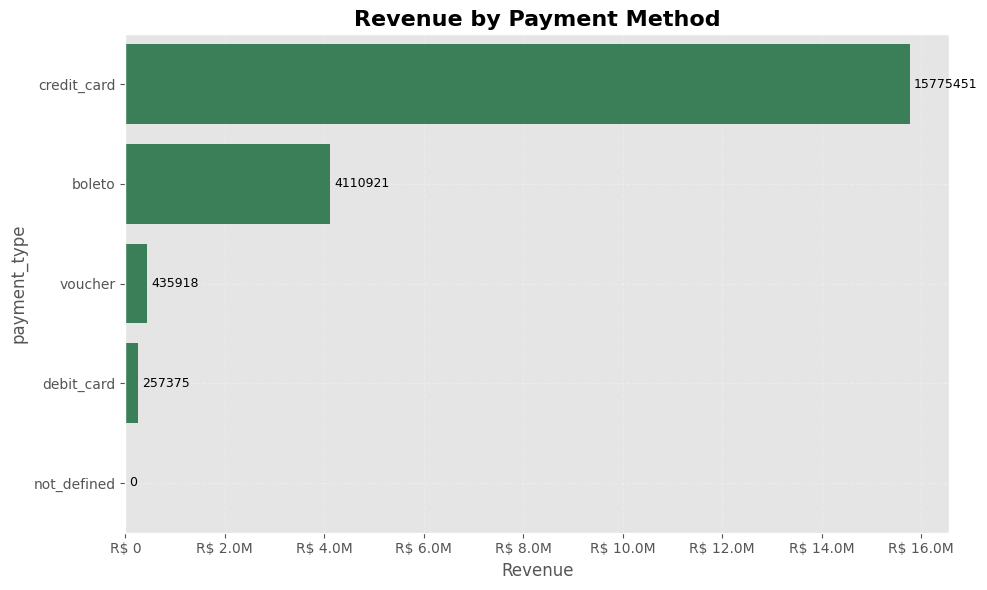

In [395]:
plot_horizontal(
    data=payment_summary,
    x="Revenue",
    y="payment_type",
    title="Revenue by Payment Method",
    currency=True
)

### Business Insight

Credit cards are the dominant payment method, contributing the largest share of total revenue. Other payment methods generate considerably lower transaction values.

### Managerial Implication

The business currently relies heavily on credit card transactions.

### Recommendation

Continue optimizing the credit card payment experience while encouraging customers to adopt alternative payment methods through targeted promotions or incentives.

## Business Question 11

### Which states have the largest customer base?

#### Business Context

Understanding customer distribution across states helps identify the company's strongest regional markets and supports strategic decisions related to marketing, logistics, and business expansion.

#### Analysis

This analysis measures the number of unique customers in each Brazilian state.

In [396]:
customer_state = (
    df.groupby("customer_state", as_index=False)
      .agg(
          Customers=("customer_unique_id", "nunique"),
          Orders=("order_id", "nunique"),
          Revenue=("payment_value", "sum")
      )
      .sort_values(
          by="Customers",
          ascending=False
      )
)

customer_state.head(10)

,customer_state,Customers,Orders,Revenue
25,SP,40302,41746,"7,726,078.35"
18,RJ,12384,12852,"2,795,615.67"
10,MG,11259,11635,"2,351,221.09"
22,RS,5277,5466,"1,160,175.66"
17,PR,4882,5045,"1,079,795.49"
23,SC,3534,3637,"801,276.45"
4,BA,3277,3380,"805,070.98"
6,DF,2075,2140,"438,095.32"
7,ES,1964,2033,"408,611.64"
8,GO,1952,2020,"520,481.65"


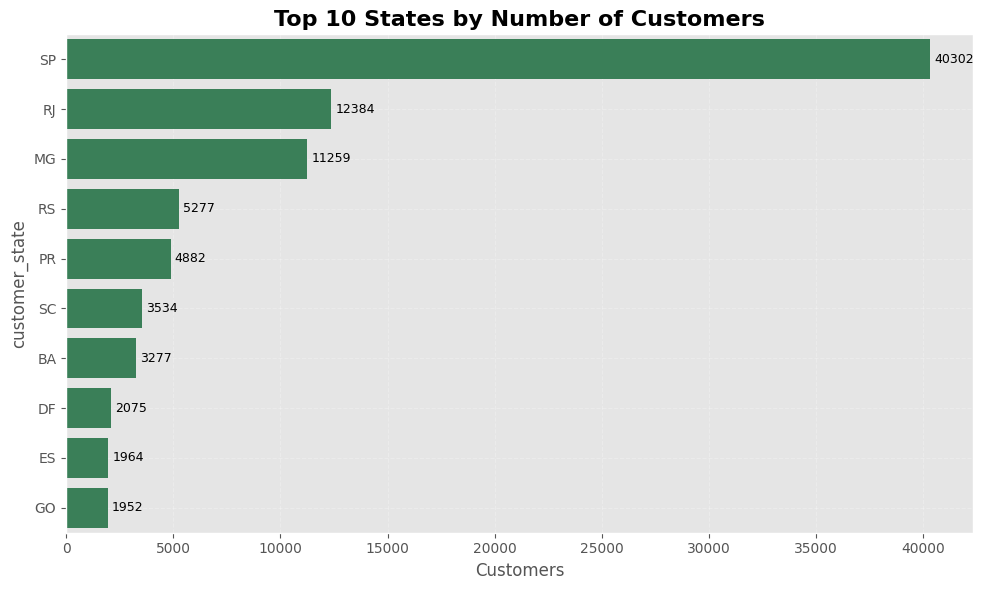

In [397]:
top10_state = customer_state.head(10)

plot_horizontal(
    data=top10_state,
    x="Customers",
    y="customer_state",
    title="Top 10 States by Number of Customers"
)

### Business Insight

São Paulo dominates Olist's customer base, followed by Rio de Janeiro and Minas Gerais. These three states represent Olist's primary markets and contribute a substantial proportion of the total customer population.

### Managerial Implication

Customer acquisition efforts have been particularly successful in Brazil's southeastern region.

### Recommendation

Continue strengthening customer acquisition and retention strategies in major markets while expanding marketing initiatives in states with lower customer penetration.  

## Business Question 12

### Which cities have the largest customer base?

#### Business Context

Customer concentration at the city level provides more granular insights for regional marketing and operational planning.

#### Analysis

The following analysis identifies the cities with the highest number of unique customers.

In [398]:
customer_city = (
    df.groupby("customer_city", as_index=False)
      .agg(
          Customers=("customer_unique_id", "nunique"),
          Orders=("order_id", "nunique"),
          Revenue=("payment_value", "sum")
      )
      .sort_values(
          by="Customers",
          ascending=False
      )
)

customer_city.head(15)

,customer_city,Customers,Orders,Revenue
3597,sao paulo,14984,15540,"2,901,789.67"
3155,rio de janeiro,6620,6882,"1,581,736.07"
453,belo horizonte,2672,2773,"509,165.81"
558,brasilia,2069,2131,"435,971.02"
1143,curitiba,1465,1521,"333,582.09"
707,campinas,1398,1444,"272,595.57"
2964,porto alegre,1326,1379,"317,995.72"
3247,salvador,1209,1245,"291,499.12"
1529,guarulhos,1153,1189,"207,174.47"
3428,sao bernardo do campo,908,938,"152,128.20"


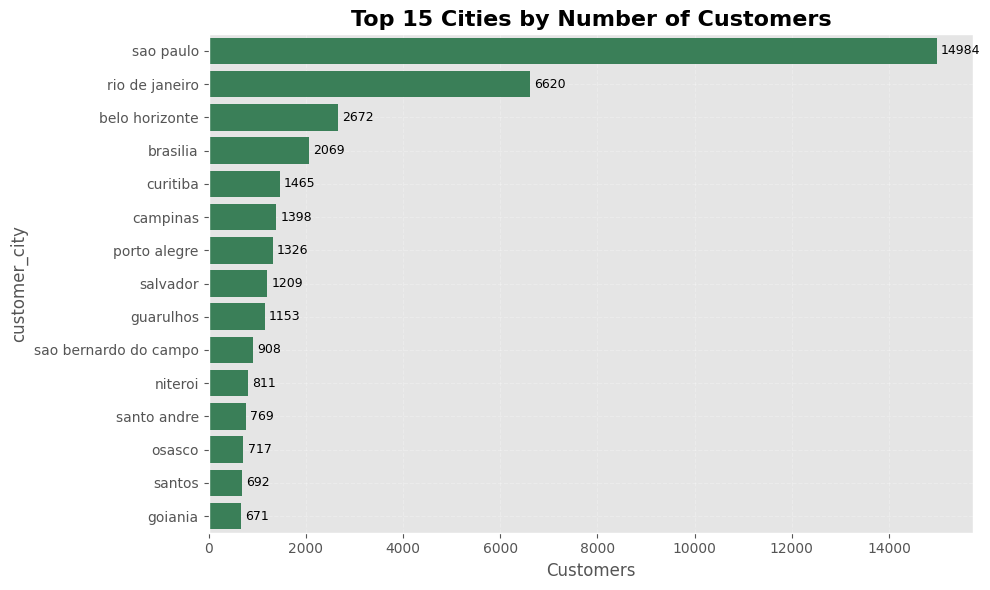

In [399]:
plot_horizontal(
    data=customer_city.head(15),
    x="Customers",
    y="customer_city",
    title="Top 15 Cities by Number of Customers"
)

### Business Insight

Major metropolitan areas dominate Olist's customer base. São Paulo City contributes the largest number of customers, followed by Rio de Janeiro, Belo Horizonte, Brasília, and Curitiba.

### Managerial Implication

Urban areas remain Olist's primary source of marketplace growth.

### Recommendation

Develop city-specific marketing campaigns while evaluating expansion opportunities in medium-sized cities with growth potential.

## Business Question 13

### Which states generate the highest revenue?

#### Business Context

A large customer base does not always translate into the highest revenue. Comparing revenue by state helps identify the company's most valuable regional markets.

#### Analysis

This analysis compares total revenue generated by customers in each state.

In [400]:
state_revenue = (
    df.groupby("customer_state", as_index=False)
      .agg(
          Revenue=("payment_value", "sum"),
          Customers=("customer_unique_id", "nunique")
      )
      .sort_values(
          by="Revenue",
          ascending=False
      )
)

state_revenue.head(10)

,customer_state,Revenue,Customers
25,SP,"7,726,078.35",40302
18,RJ,"2,795,615.67",12384
10,MG,"2,351,221.09",11259
22,RS,"1,160,175.66",5277
17,PR,"1,079,795.49",4882
4,BA,"805,070.98",3277
23,SC,"801,276.45",3534
8,GO,"520,481.65",1952
6,DF,"438,095.32",2075
7,ES,"408,611.64",1964


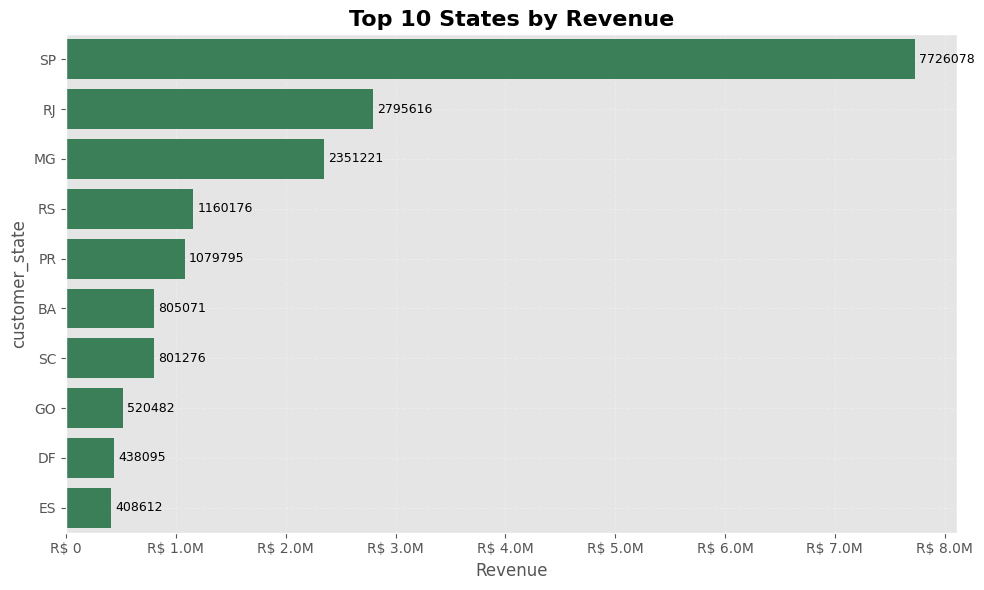

In [401]:
plot_horizontal(
    data=state_revenue.head(10),
    x="Revenue",
    y="customer_state",
    title="Top 10 States by Revenue",
    currency=True
)

### Business Insight

The same states that dominate customer acquisition also generate the highest revenue. São Paulo contributes the largest share of marketplace revenue, followed by Rio de Janeiro and Minas Gerais.

### Managerial Implication

The southeastern region remains Olist's most valuable business market, both in customer volume and revenue generation.

### Recommendation

Protect Olist's market leadership in these states while gradually expanding into underrepresented regions to diversify future revenue sources.

# Customer Analytics

Customer Analytics focuses on identifying valuable customer segments, understanding revenue concentration, and estimating customer value.

The analyses in this section include:

- RFM Analysis
- Pareto Analysis
- Customer Lifetime Value (CLV)

## Business Question 14

### Which customer segments contribute the most value?

#### Business Context

Not every customer contributes equally to business performance.

RFM (Recency, Frequency, Monetary) analysis helps classify customers based on purchasing behavior, enabling businesses to design personalized marketing strategies and improve customer retention.

#### Analysis

Customers are segmented using Recency, Frequency, and Monetary metrics.

In [402]:
snapshot_date = (
    df["order_year_month"].max() +
    pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2018-10-02 00:00:00')

In [403]:
rfm = (
    df.groupby("customer_unique_id")
      .agg(
          Recency=(
              "order_year_month",
              lambda x: (snapshot_date - x.max()).days
          ),

          Frequency=(
              "order_id",
              "nunique"
          ),

          Monetary=(
              "payment_value",
              "sum"
          )
      )
      .reset_index()
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,154,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,154,1,27.19
2,0000f46a3911fa3c0805444483337064,580,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,366,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,335,1,196.89


In [404]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,"96,096.00","96,096.00","96,096.00"
mean,287.61,1.03,214.16
std,153.62,0.21,644.89
min,1.00,1.00,0.00
25%,154.00,1.00,64.00
50%,274.00,1.00,113.34
75%,396.00,1.00,203.42
max,761.00,17.00,"109,312.64"


In [405]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [406]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,154,1,141.90,5,1,4,514
1,0000b849f77a49e4a4ce2b2a4ca5be3f,154,1,27.19,5,1,1,511
2,0000f46a3911fa3c0805444483337064,580,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,366,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,335,1,196.89,2,1,4,214


In [407]:
def customer_segment(row):

    score = (
        int(row["R_Score"])
        + int(row["F_Score"])
        + int(row["M_Score"])
    )

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 8:
        return "Potential Loyalists"

    elif score >= 6:
        return "Need Attention"

    else:
        return "At Risk"

rfm["Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

In [408]:
segment_summary = (
    rfm.groupby("Segment", as_index=False)
       .agg(
           Customers=("customer_unique_id", "count"),
           Avg_Monetary=("Monetary", "mean"),
           Avg_Frequency=("Frequency", "mean")
       )
)

segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "Need Attention",
    "At Risk"
]

segment_summary["Segment"] = pd.Categorical(
    segment_summary["Segment"],
    categories=segment_order,
    ordered=True
)

segment_summary = (
    segment_summary
    .sort_values("Segment")
)

segment_summary

,Segment,Customers,Avg_Monetary,Avg_Frequency
1,Champions,9084,475.13,1.20
2,Loyal Customers,32913,275.47,1.04
4,Potential Loyalists,27681,174.69,1.01
3,Need Attention,18563,103.08,1.00
0,At Risk,7855,57.03,1.00


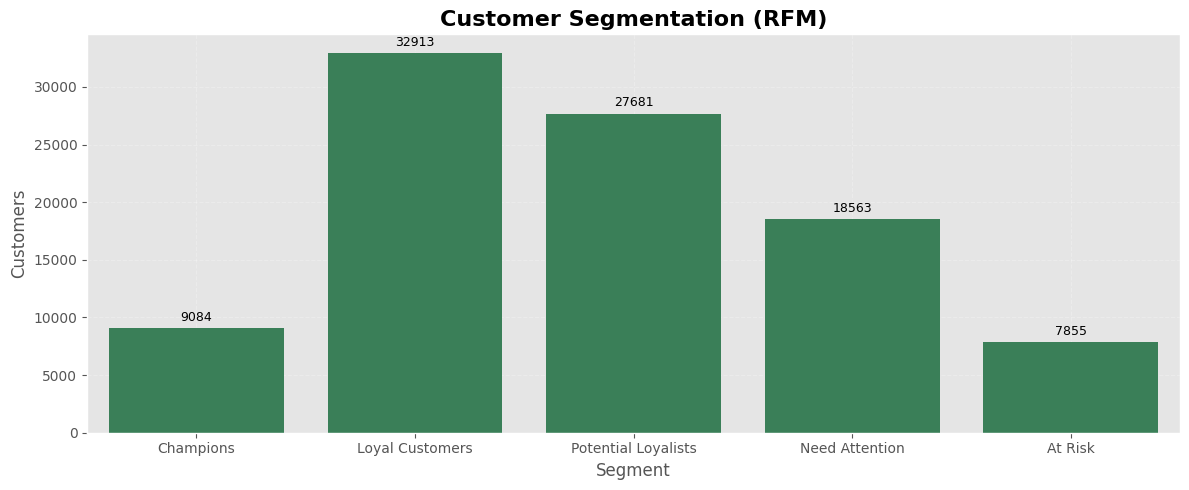

In [409]:
plot_bar(
    data=segment_summary,
    x="Segment",
    y="Customers",
    title="Customer Segmentation (RFM)"
)

In [410]:
segment_summary["Customer Share (%)"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
).round(2)

segment_summary

,Segment,Customers,Avg_Monetary,Avg_Frequency,Customer Share (%)
1,Champions,9084,475.13,1.20,9.45
2,Loyal Customers,32913,275.47,1.04,34.25
4,Potential Loyalists,27681,174.69,1.01,28.81
3,Need Attention,18563,103.08,1.00,19.32
0,At Risk,7855,57.03,1.00,8.17


### Business Insight

The RFM analysis reveals that **Loyal Customers** represent the largest customer segment, followed by **Potential Loyalists**.

A relatively small group of **Champions** contributes substantial business value, while **Need Attention** and **At Risk** customers indicate opportunities for customer retention initiatives.

#### Managerial Implication

Different customer segments require different engagement strategies.

#### Recommendation

- Reward Champions through exclusive loyalty programs.
- Convert Potential Loyalists into repeat customers.
- Re-engage Need Attention and At Risk customers through personalized campaigns.

## Business Question 15

### Do a small percentage of customers contribute the majority of total revenue?

#### Business Context

Many businesses follow the Pareto Principle (80/20 Rule), where a relatively small percentage of customers generate the majority of revenue.

Understanding revenue concentration helps management prioritize customer retention strategies and allocate marketing resources more effectively.

#### Analysis

This analysis evaluates cumulative customer revenue contribution and compares it with the traditional Pareto Principle.

In [411]:
customer_revenue = (
    df.groupby("customer_unique_id", as_index=False)
      .agg(
          Revenue=("payment_value", "sum")
      )
      .sort_values(
          by="Revenue",
          ascending=False
      )
)

customer_revenue.head()

,customer_unique_id,Revenue
3826,0a0a92112bd4c708ca5fde585afaa872,"109,312.64"
39720,698e1cf81d01a3d389d96145f7fa6df8,"45,256.00"
73664,c402f431464c72e27330a67f7b94d4fb,"44,048.00"
24121,4007669dec559734d6f53e029e360987,"36,489.24"
90000,ef8d54b3797ea4db1d63f0ced6a906e9,"30,186.00"


In [412]:
customer_revenue["Cumulative Revenue"] = (
    customer_revenue["Revenue"]
    .cumsum()
)

customer_revenue["Revenue Share (%)"] = (
    customer_revenue["Cumulative Revenue"]
    / customer_revenue["Revenue"].sum()
    * 100
)

customer_revenue["Customer Share (%)"] = (
    np.arange(1, len(customer_revenue) + 1)
    / len(customer_revenue)
    * 100
)

customer_revenue.head()

,customer_unique_id,Revenue,Cumulative Revenue,Revenue Share (%),Customer Share (%)
3826,0a0a92112bd4c708ca5fde585afaa872,"109,312.64","109,312.64",0.53,0.00
39720,698e1cf81d01a3d389d96145f7fa6df8,"45,256.00","154,568.64",0.75,0.00
73664,c402f431464c72e27330a67f7b94d4fb,"44,048.00","198,616.64",0.97,0.00
24121,4007669dec559734d6f53e029e360987,"36,489.24","235,105.88",1.14,0.00
90000,ef8d54b3797ea4db1d63f0ced6a906e9,"30,186.00","265,291.88",1.29,0.01


In [413]:
top20 = customer_revenue[
    customer_revenue["Customer Share (%)"] <= 20
]

top20_revenue = (
    top20["Revenue"].sum()
    / customer_revenue["Revenue"].sum()
    * 100
)

pareto_summary = pd.DataFrame({

    "Metric":[
        "Top 20% Customer Revenue Contribution"
    ],

    "Value (%)":[
        round(top20_revenue,2)
    ]

})

pareto_summary

,Metric,Value (%)
0,Top 20% Customer Revenue Contribution,61.95


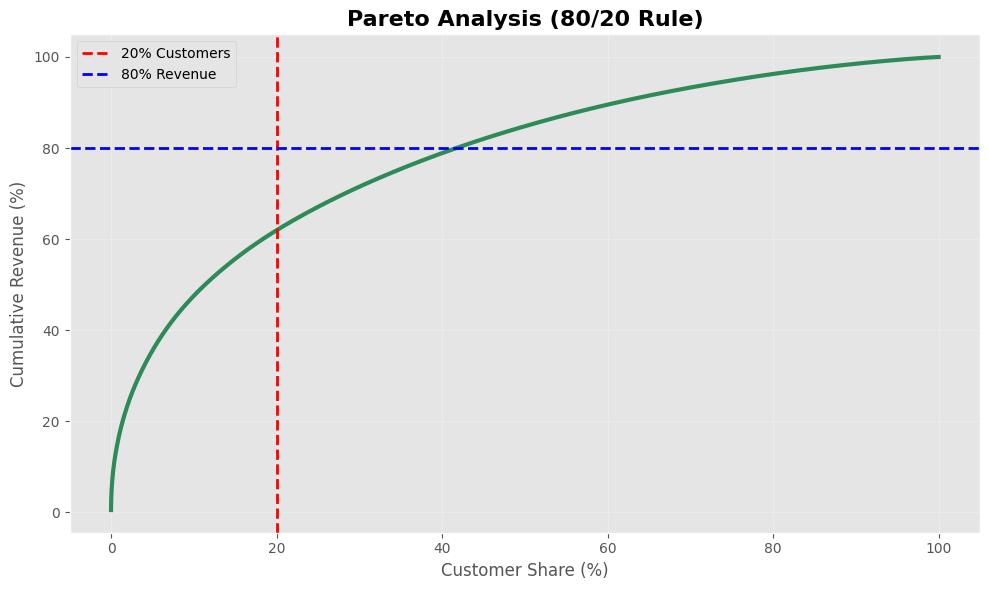

In [414]:
plt.figure(figsize=(10,6))

plt.plot(
    customer_revenue["Customer Share (%)"],
    customer_revenue["Revenue Share (%)"],
    color=PRIMARY,
    linewidth=3
)

plt.axvline(
    20,
    linestyle="--",
    color="red",
    linewidth=2,
    label="20% Customers"
)

plt.axhline(
    80,
    linestyle="--",
    color="blue",
    linewidth=2,
    label="80% Revenue"
)

plt.xlabel("Customer Share (%)")

plt.ylabel("Cumulative Revenue (%)")

plt.title(
    "Pareto Analysis (80/20 Rule)",
    fontsize=TITLE_SIZE,
    weight="bold"
)

plt.grid(alpha=.25)

plt.legend()

plt.tight_layout()

plt.show()

### Business Insight

The analysis shows that the top **20% of customers contribute approximately 62% of total revenue**, indicating that Olist does not strictly follow the traditional Pareto Principle (80/20 Rule).

Revenue is more evenly distributed across the customer base, suggesting that business performance depends on maintaining a broad customer population rather than relying on only a small group of high-value customers.

#### Managerial Implication

The marketplace benefits from a diversified revenue structure, reducing dependence on a limited number of premium customers.

#### Recommendation

Continue strengthening customer acquisition while maintaining loyalty programs for high-value customers to sustain long-term revenue growth.

## Business Question 16

### What is the estimated Customer Lifetime Value (CLV)?

#### Business Context

Customer Lifetime Value (CLV) estimates the revenue generated by each customer throughout their relationship with the business.

Understanding CLV helps identify valuable customers and supports customer retention strategies.

#### Analysis

The following analysis estimates customer lifetime value using historical transaction data.

In [415]:
clv = (
    df.groupby("customer_unique_id", as_index=False)
      .agg(
          Total_Revenue=("payment_value","sum"),
          Total_Orders=("order_id","nunique")
      )
)

clv["Average_Order_Value"] = (
    clv["Total_Revenue"]
    / clv["Total_Orders"]
)

clv.head()

,customer_unique_id,Total_Revenue,Total_Orders,Average_Order_Value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89


In [416]:
clv.describe().round(2)

,Total_Revenue,Total_Orders,Average_Order_Value
count,"96,096.00","96,096.00","96,096.00"
mean,214.16,1.03,206.07
std,644.89,0.21,619.05
min,0.00,1.00,0.00
25%,64.00,1.00,63.27
50%,113.34,1.00,111.02
75%,203.42,1.00,196.36
max,"109,312.64",17.00,"109,312.64"


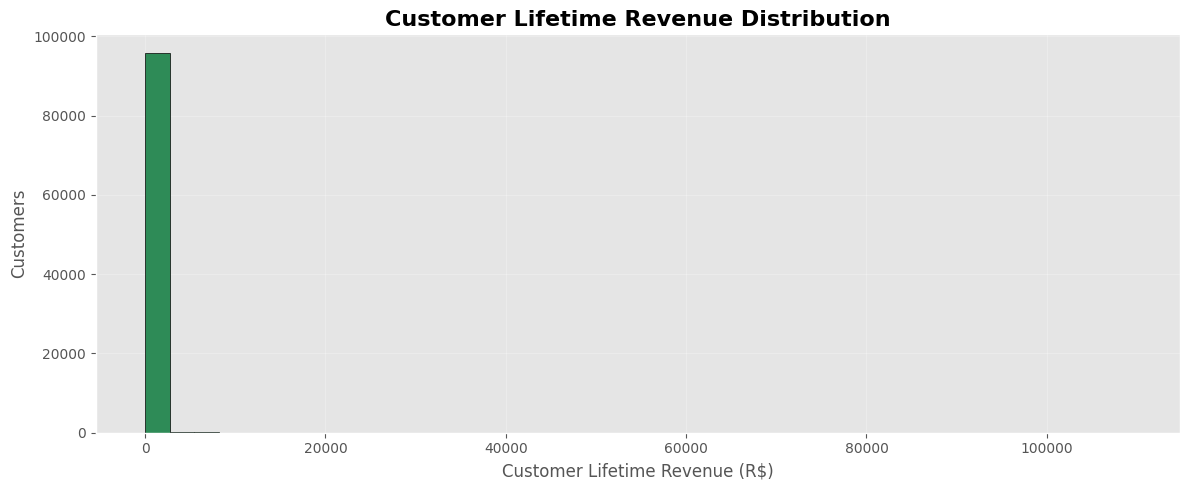

In [417]:
plt.figure(figsize=FIGSIZE)

plt.hist(
    clv["Total_Revenue"],
    bins=40,
    color=PRIMARY,
    edgecolor="black"
)

plt.title(
    "Customer Lifetime Revenue Distribution",
    fontsize=TITLE_SIZE,
    weight="bold"
)

plt.xlabel("Customer Lifetime Revenue (R$)")
plt.ylabel("Customers")

plt.grid(alpha=.25)

plt.tight_layout()

plt.show()

In [418]:
top_customer = (
    clv.sort_values(
        by="Total_Revenue",
        ascending=False
    )
    .head(10)
    .copy()
)

top_customer["Customer"] = [
    f"Customer {i}"
    for i in range(1,11)
]

top_customer

,customer_unique_id,Total_Revenue,Total_Orders,Average_Order_Value,Customer
3826,0a0a92112bd4c708ca5fde585afaa872,"109,312.64",1,"109,312.64",Customer 1
39720,698e1cf81d01a3d389d96145f7fa6df8,"45,256.00",1,"45,256.00",Customer 2
73664,c402f431464c72e27330a67f7b94d4fb,"44,048.00",1,"44,048.00",Customer 3
24121,4007669dec559734d6f53e029e360987,"36,489.24",1,"36,489.24",Customer 4
90000,ef8d54b3797ea4db1d63f0ced6a906e9,"30,186.00",1,"30,186.00",Customer 5
44447,763c8b1c9c68a0229c42c9fc6f662b93,"29,099.52",1,"29,099.52",Customer 6
75269,c8460e4251689ba205045f3ea17884a1,"27,935.46",4,"6,983.87",Customer 7
88262,eae0a83d752b1dd32697e0e7b4221656,"25,051.89",2,"12,525.94",Customer 8
23071,3d47f4368ccc8e1bb4c4a12dbda7111b,"22,346.60",1,"22,346.60",Customer 9
65407,adfa1cab2b2c8706db21bb13c0a1beb1,"19,457.04",1,"19,457.04",Customer 10


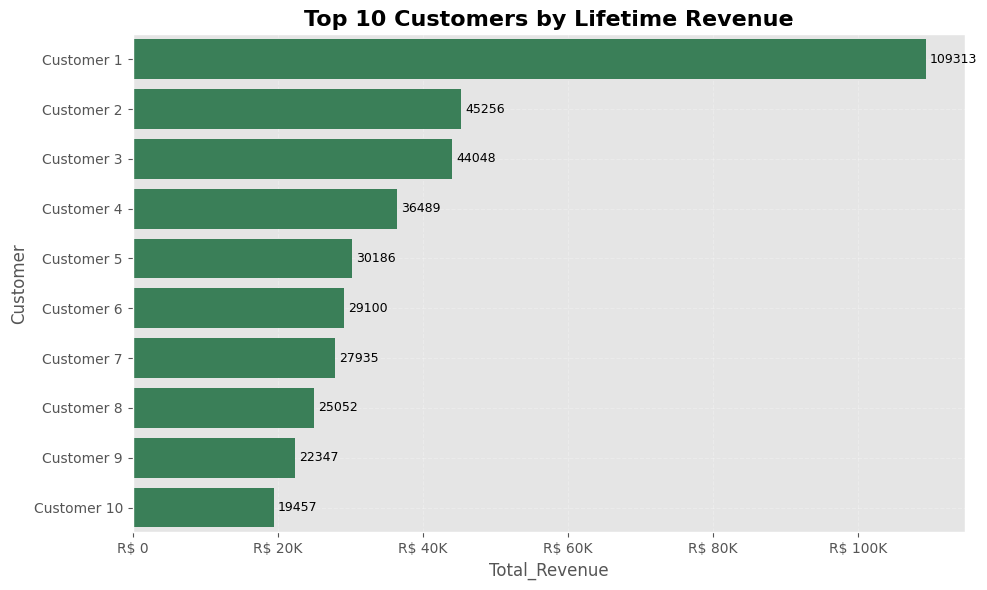

In [419]:
plot_horizontal(
    data=top_customer,
    x="Total_Revenue",
    y="Customer",
    title="Top 10 Customers by Lifetime Revenue",
    currency=True
)

### Business Insight

Customer Lifetime Value is highly skewed, indicating that most customers generate relatively low lifetime revenue, while a small group of premium customers contributes substantially higher revenue.

The average customer places approximately one order during the observation period, suggesting considerable opportunities to improve customer retention and repeat purchasing.

#### Managerial Implication

Increasing repeat purchases represents one of the largest opportunities for future business growth.

#### Recommendation

Implement personalized retention campaigns, loyalty programs, and cross-selling initiatives to increase Customer Lifetime Value over time.

# Operational Analysis

Operational performance plays a critical role in customer satisfaction and long-term business success.

This section evaluates delivery performance, customer satisfaction, and relationships among key business variables.

## Business Question 17

### How efficient is the delivery process?

#### Business Context

Delivery performance directly affects customer satisfaction and repeat purchases. Monitoring delivery time helps evaluate logistics efficiency.

#### Analysis

The following analysis summarizes the delivery time experienced by customers.

In [420]:
delivery_summary = pd.DataFrame({

    "Metric":[
        "Average Delivery Time (Days)",
        "Fastest Delivery",
        "Longest Delivery"
    ],

    "Value":[
        round(df["delivery_time"].mean(),2),
        round(df["delivery_time"].min(),2),
        round(df["delivery_time"].max(),2)
    ]

})

delivery_summary

,Metric,Value
0,Average Delivery Time (Days),12.02
1,Fastest Delivery,0.00
2,Longest Delivery,209.00


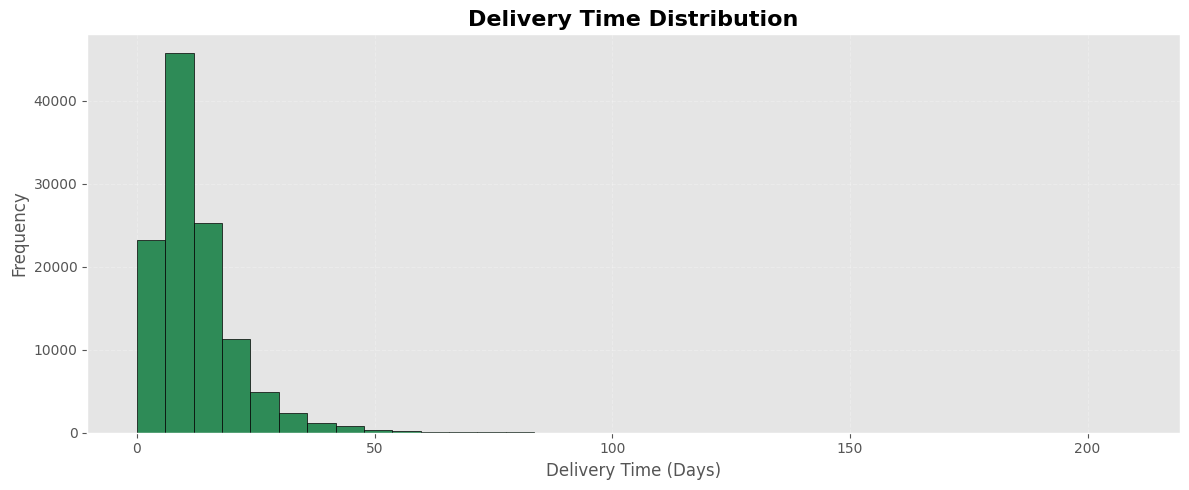

In [421]:
plt.figure(figsize=FIGSIZE)

plt.hist(
    df["delivery_time"].dropna(),
    bins=35,
    color=PRIMARY,
    edgecolor="black"
)

plt.title(
    "Delivery Time Distribution",
    fontsize=TITLE_SIZE,
    weight="bold"
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")

plt.grid(alpha=.25, linestyle="--")

plt.tight_layout()

plt.show()

### Business Insight

Most deliveries are completed within a relatively short period, although a small number of orders experience significantly longer delivery times.

#### Managerial Implication

Reducing delivery variability may improve customer experience and increase customer retention.

#### Recommendation

Identify logistics partners or regions associated with long delivery times and implement targeted operational improvements.

## Business Question 18

### How satisfied are customers?

#### Business Context

Customer reviews provide valuable feedback regarding shopping experience and service quality.

#### Analysis

This analysis evaluates the distribution of customer review scores.

In [422]:
review_summary = (
    df.groupby("review_score", as_index=False)
      .agg(
          Orders=("order_id","nunique")
      )
)

review_summary

,review_score,Orders
0,1.00,11393
1,2.00,3148
2,3.00,8160
3,4.00,19098
4,5.00,57076


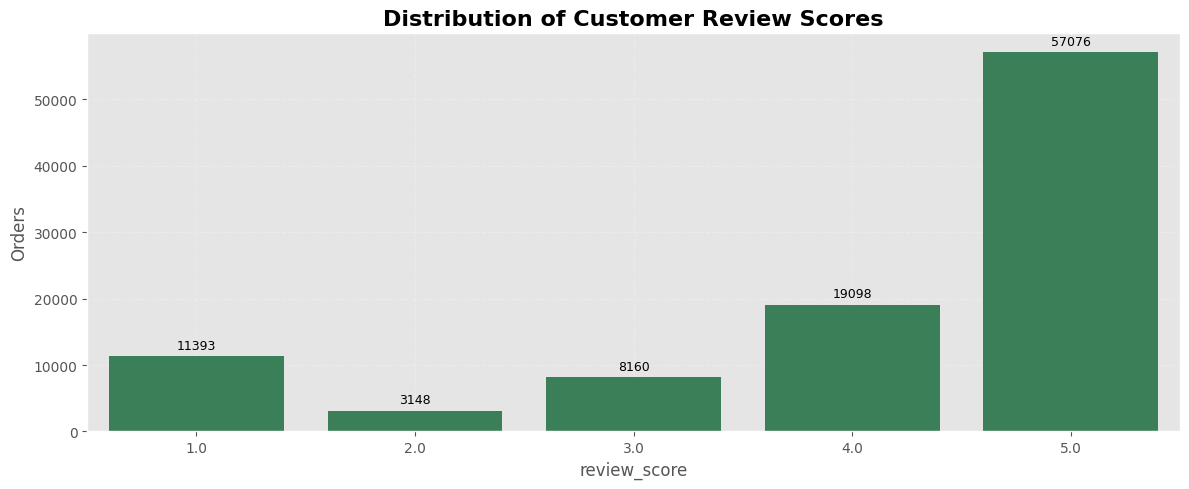

In [423]:
plot_bar(
    data=review_summary,
    x="review_score",
    y="Orders",
    title="Distribution of Customer Review Scores"
)

### Business Insight

Most customers provide high review scores, indicating a generally positive shopping experience. However, lower ratings still exist and represent opportunities for service improvement.

#### Managerial Implication

Customer satisfaction remains one of Olist's strengths but requires continuous monitoring.

#### Recommendation

Investigate low-rated orders to identify recurring service issues and improve customer experience.

## Business Question 19

### Is there a relationship between business variables?

#### Business Context

Understanding correlations among numerical variables helps identify potential business relationships and supports future predictive analytics.

#### Analysis

A correlation matrix is generated using key numerical variables.

In [424]:
corr = df[[
    "payment_value",
    "review_score",
    "delivery_time"
]].corr()

corr

,payment_value,review_score,delivery_time
payment_value,1.00,-0.08,0.06
review_score,-0.08,1.00,-0.30
delivery_time,0.06,-0.30,1.00


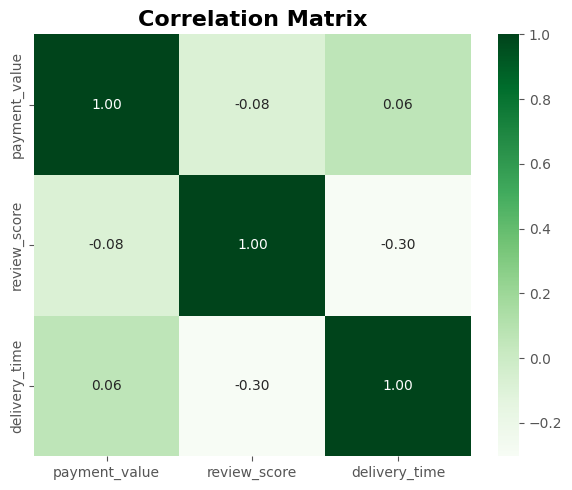

In [425]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Greens",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=TITLE_SIZE,
    weight="bold"
)

plt.tight_layout()

plt.show()

### Business Insight

The correlation analysis indicates that relationships among payment value, delivery time, and review score are relatively weak. This suggests that customer satisfaction is influenced by multiple factors rather than a single operational metric.

#### Managerial Implication

Business decisions should consider multiple dimensions instead of relying on a single KPI.

#### Recommendation

Combine operational, customer, and sales metrics when evaluating business performance.

# Executive Summary

The business analysis reveals several important findings:

- Revenue and order volume increased consistently over time.
- Customer growth supported long-term marketplace expansion.
- Revenue is concentrated during seasonal shopping periods.
- Credit cards dominate customer payment preferences.
- The southeastern region contributes the largest customer base and revenue.
- Most customers make relatively low-value purchases, while a small group of high-value customers generates significant revenue.
- Customer satisfaction is generally high.
- Delivery performance is satisfactory but still has opportunities for improvement.

# Strategic Recommendations

Based on the analysis, several strategic initiatives are recommended:

### Sales

- Prepare inventory before seasonal demand.
- Increase Average Order Value through cross-selling and upselling.

### Customer

- Reward Champions through loyalty programs.
- Re-engage At Risk customers using personalized campaigns.
- Improve customer retention to increase Customer Lifetime Value.

### Operations

- Improve delivery consistency.
- Monitor low review scores.
- Expand logistics capacity during peak seasons.

### Business Intelligence

- Develop an interactive Power BI dashboard to monitor business performance in real time.

# Next Steps

The analytical findings presented in this notebook will be implemented in the next stage of the project:

- Interactive Power BI Dashboard
- Executive Business Report
- GitHub Portfolio Documentation